# PROJECT: EMPLOYEE TURNOVER USING MACHINE LEARNING ALGORITHM

**Aim:** Built a predictive model leveraging Logistic Regression, Random Forest Classifier, Gradient Boosting Classifier, and K-means clustering to Predict employees attrition.

**Dataset Used:** `'HR_comma_sep.csv'`

**Tools:** Numpy, Pandas, Matplotlib, Seaborn etc.

In [1]:
##### Import core libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning utilities
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score


# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans

# SMOTE for handling class imbalance
from imblearn.over_sampling import SMOTE

# To suppress warnings
import warnings
warnings.filterwarnings("ignore")


In [2]:
# Load the dataset
df = pd.read_csv("HR_comma_sep.csv")

# Display first 5 rows
df.head(20).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
satisfaction_level,0.38,0.8,0.11,0.72,0.37,0.41,0.1,0.92,0.89,0.42,0.45,0.11,0.84,0.41,0.36,0.38,0.45,0.78,0.45,0.76
last_evaluation,0.53,0.86,0.88,0.87,0.52,0.5,0.77,0.85,1.0,0.53,0.54,0.81,0.92,0.55,0.56,0.54,0.47,0.99,0.51,0.89
number_project,2,5,7,5,2,2,6,5,5,2,2,6,4,2,2,2,2,4,2,5
average_montly_hours,157,262,272,223,159,153,247,259,224,142,135,305,234,148,137,143,160,255,160,262
time_spend_company,3,6,4,5,3,3,4,5,5,3,3,4,5,3,3,3,3,6,3,5
Work_accident,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
left,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
promotion_last_5years,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
sales,sales,sales,sales,sales,sales,sales,sales,sales,sales,sales,sales,sales,sales,sales,sales,sales,sales,sales,sales,sales
salary,low,medium,medium,low,low,low,low,low,low,low,low,low,low,low,low,low,low,low,low,low


In [3]:
# Check number of rows and columns
df.shape

(14999, 10)

In [4]:
# Check data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Dataset Overview
- The dataset contains employee-related information such as satisfaction level,
  evaluation scores, project count, working hours, experience, and salary.
- The target variable is **left**, where:
  - ***0 indicates employee stayed***
  - ***1 indicates employee left the company***
- The dataset consists of both numerical and categorical variables, which will
  require preprocessing before modeling.

In [5]:
# Check for missing values in each column
df.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

### Data Quality Check – Missing Values
- The dataset does not contain any missing values.
- Hence, no imputation or removal of records is required.
- The data is clean and suitable for further exploratory data analysis (EDA).

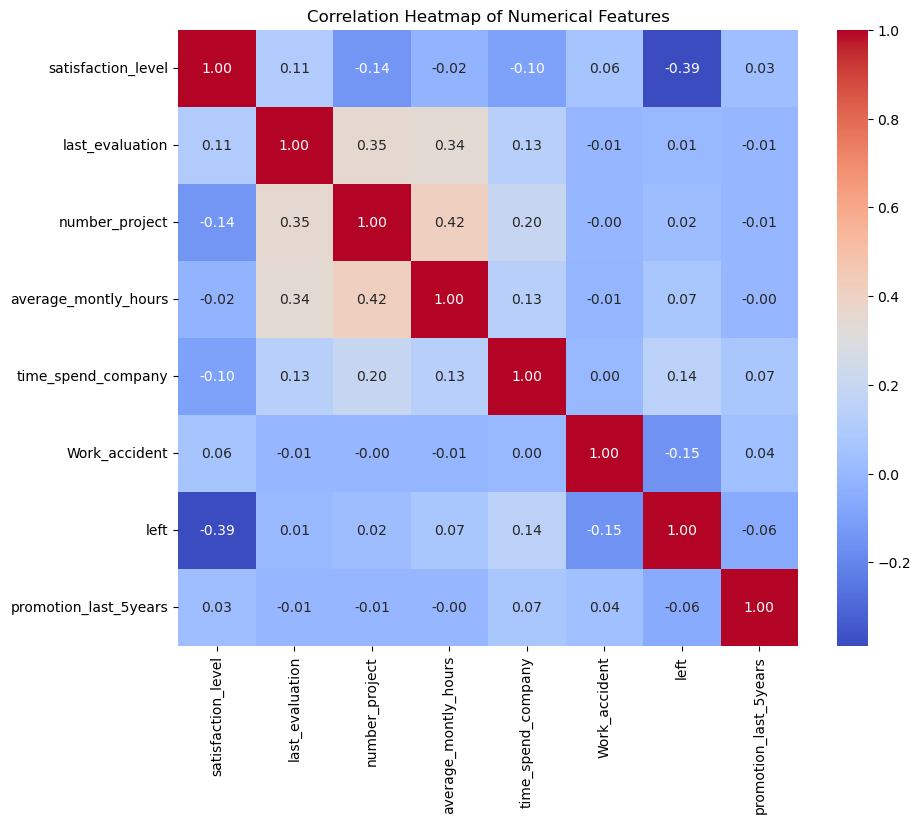

In [6]:
# Select only numerical columns
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numerical_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

### Correlation Analysis
- Employee turnover (`left`) shows noticeable correlation with:
  - Satisfaction level (negative correlation)
  - Time spent in the company
  - Number of projects
  - Average monthly working hours
- Satisfaction level is negatively correlated with employee turnover, indicating
  that employees with lower satisfaction are more likely to leave.
- This heatmap helps identify key features influencing employee attrition.


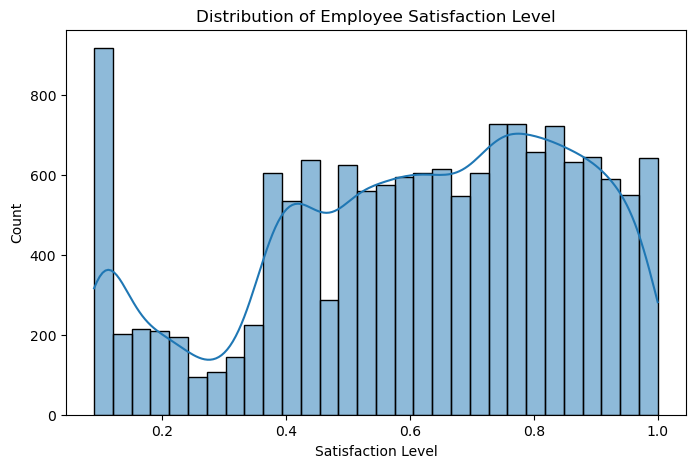

In [7]:
# Distribution of Satisfaction Level
plt.figure(figsize=(8, 5))
sns.histplot(df['satisfaction_level'], bins=30, kde=True)
plt.title("Distribution of Employee Satisfaction Level")
plt.xlabel("Satisfaction Level")
plt.ylabel("Count")
plt.show()

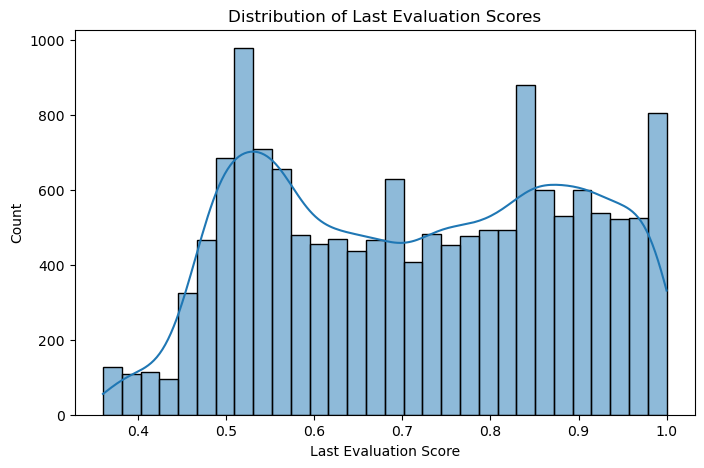

In [8]:
# Distribution of Last Evaluation Score
plt.figure(figsize=(8, 5))
sns.histplot(df['last_evaluation'], bins=30, kde=True)
plt.title("Distribution of Last Evaluation Scores")
plt.xlabel("Last Evaluation Score")
plt.ylabel("Count")
plt.show()

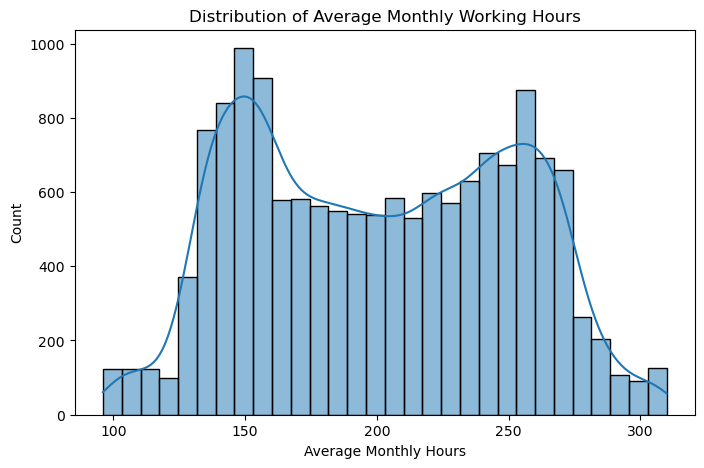

In [9]:
# Distribution of Average Monthly Working Hours
plt.figure(figsize=(8, 5))
sns.histplot(df['average_montly_hours'], bins=30, kde=True)
plt.title("Distribution of Average Monthly Working Hours")
plt.xlabel("Average Monthly Hours")
plt.ylabel("Count")
plt.show()

### Distribution Analysis
- Satisfaction levels are skewed towards the lower side for employees who left,
  indicating dissatisfaction as a key factor in attrition.
- Evaluation scores are mostly concentrated in the mid to high range, suggesting
  that both high and low performers may leave.
- Monthly working hours show multiple peaks, indicating different employee work
  patterns, possibly contributing to turnover.


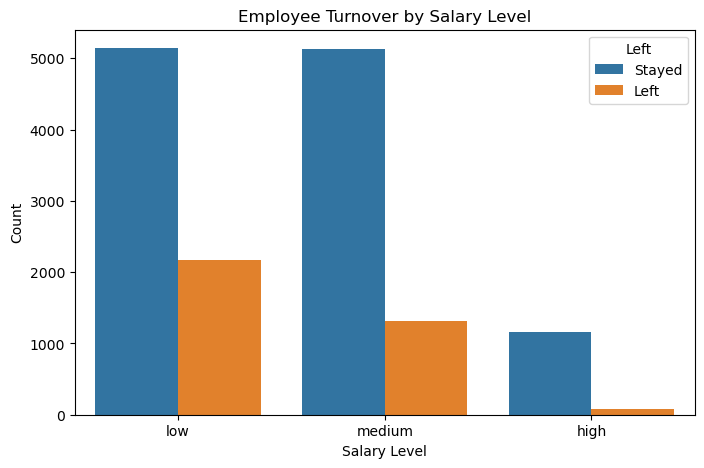

In [10]:
# Employee Turnover by Salary Level
plt.figure(figsize=(8, 5))
sns.countplot(x='salary', hue='left', data=df)
plt.title("Employee Turnover by Salary Level")
plt.xlabel("Salary Level")
plt.ylabel("Count")
plt.legend(title="Left", labels=["Stayed", "Left"])
plt.show()

In [11]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'sales', 'salary'],
      dtype='object')

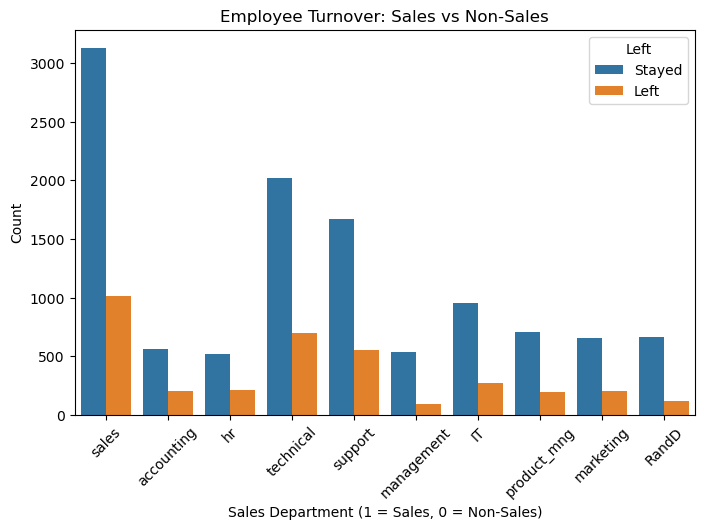

In [12]:
# Employee Turnover: Sales vs Non-Sales
plt.figure(figsize=(8, 5))
sns.countplot(x='sales', hue='left', data=df)
plt.title("Employee Turnover: Sales vs Non-Sales")
plt.xlabel("Sales Department (1 = Sales, 0 = Non-Sales)")
plt.ylabel("Count")
plt.xticks(rotation=45) 
plt.legend(title="Left", labels=["Stayed", "Left"])
plt.show()


### Department-Based Analysis
- The dataset contains department information in a one-hot encoded format.
- The `sales` column indicates whether an employee belongs to the Sales department.
- Employees in the Sales department show a higher tendency to leave compared to
  employees from other departments.
- Departmental affiliation is an important factor influencing employee attrition.


**Filter Employees Who Left the Company**

In [13]:
# Filter only employees who left
df_left = df[df['left'] == 1]

# Check shape
df_left.shape

(3571, 10)

### Filtering Employees Who Left
- For clustering analysis, only employees who left the company are considered.
- This helps in identifying different behavioral patterns among employees who exited.


## Select Columns for Clustering

In [14]:
# Select required columns for clustering
X_cluster = df_left[['satisfaction_level', 'last_evaluation']]

X_cluster.head()


,satisfaction_level,last_evaluation
0,0.38,0.53
1,0.80,0.86
2,0.11,0.88
3,0.72,0.87
4,0.37,0.52


### Feature Selection for Clustering
- Satisfaction level and last evaluation score are chosen as clustering features.
- These variables help understand performance and satisfaction patterns
  among employees who left.


In [15]:
# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df_left['cluster'] = kmeans.fit_predict(X_cluster)

# View cluster counts
df_left['cluster'].value_counts()


cluster
0    1650
1     977
2     944
Name: count, dtype: int64

## Visualize the Clusters

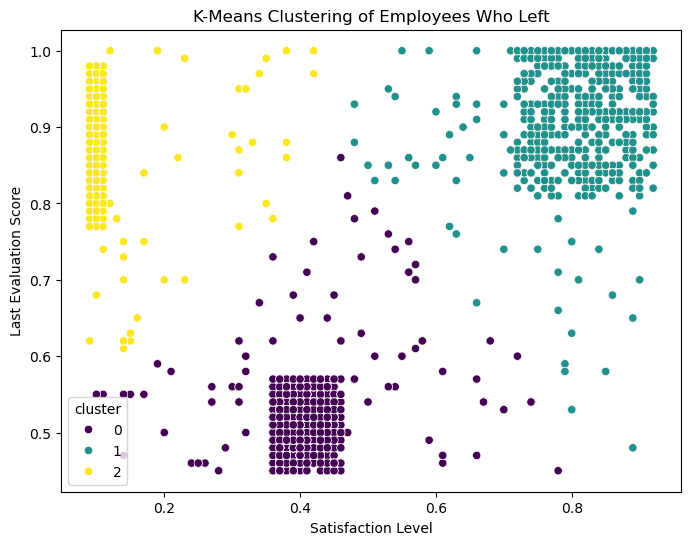

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='satisfaction_level',
    y='last_evaluation',
    hue='cluster',
    data=df_left,
    palette='viridis'
)
plt.title("K-Means Clustering of Employees Who Left")
plt.xlabel("Satisfaction Level")
plt.ylabel("Last Evaluation Score")
plt.show()

### Cluster Interpretation
- Cluster 0 represents employees with low satisfaction but relatively high evaluation scores,
  indicating overworked or underappreciated high performers.
- Cluster 1 consists of employees with moderate satisfaction and evaluation scores.
- Cluster 2 includes employees with low satisfaction and low evaluation scores,
  indicating disengaged employees.
- These clusters highlight different reasons for employee attrition and can help
  HR design targeted retention strategies.


## Separate Target Variable

In [17]:
# Separate features and target
X = df.drop('left', axis=1)
y = df['left']

X.shape[0], y.shape[0]

(14999, 14999)

## Identify Categorical and Numerical Columns

In [18]:
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(exclude='object').columns

categorical_cols, numerical_cols

(Index(['sales', 'salary'], dtype='object'),
 Index(['satisfaction_level', 'last_evaluation', 'number_project',
        'average_montly_hours', 'time_spend_company', 'Work_accident',
        'promotion_last_5years'],
       dtype='object'))

# Apply One-Hot Encoding to Categorical Variables

In [40]:
# Apply one-hot encoding to categorical variables
X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

X_encoded.head(20)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,0,False,False,False,False,False,False,True,False,False,True,False
5,0.41,0.50,2,153,3,0,0,False,False,False,False,False,False,True,False,False,True,False
6,0.10,0.77,6,247,4,0,0,False,False,False,False,False,False,True,False,False,True,False
7,0.92,0.85,5,259,5,0,0,False,False,False,False,False,False,True,False,False,True,False
8,0.89,1.00,5,224,5,0,0,False,False,False,False,False,False,True,False,False,True,False
9,0.42,0.53,2,142,3,0,0,False,False,False,False,False,False,True,False,False,True,False


### Data Pre-processing
- The target variable `left` was separated from the feature set.
- Categorical variables (`sales` and `salary`) were identified and converted
  into numerical format using one-hot encoding.
- The dataset is now fully numerical and suitable for machine learning models.

## Train-Test Split (80:20 with random_state=123)

In [20]:
# Perform stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded,y,test_size=0.2,random_state=123,stratify=y)

X_train.shape, X_test.shape


((11999, 18), (3000, 18))

### Train–Test Split
- The dataset was split into training (80%) and testing (20%) sets.
- Stratification was applied to preserve the original class distribution.
- This ensures unbiased model evaluation.


# Check Class Distribution Before SMOTE

In [21]:
# Class distribution before SMOTE
y_train.value_counts()


left
0    9142
1    2857
Name: count, dtype: int64

- ***There is huge class imbalance on this dataset***

# Apply SMOTE on Training Data

In [22]:
# Apply SMOTE to balance the classes
smote = SMOTE(random_state=123)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

y_train_smote.value_counts()

left
0    9142
1    9142
Name: count, dtype: int64

### Handling Class Imbalance using SMOTE
- The training dataset showed a significant class imbalance.
- SMOTE (Synthetic Minority Over-sampling Technique) was applied to generate
  synthetic samples for the minority class.
- After SMOTE, both classes are equally represented, improving model learning
  and prediction fairness.


# Standardize the Features

In [23]:
# Standardize features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression with 5-Fold Cross-Validation

In [24]:
# Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, random_state=123)

# 5-fold cross-validation predictions
y_train_pred_lr = cross_val_predict(
    log_reg,
    X_train_scaled,
    y_train_smote,
    cv=5
)

# Fit model on full training data
log_reg.fit(X_train_scaled, y_train_smote)

# Predict on test data
y_test_pred_lr = log_reg.predict(X_test_scaled)

# Classification report
print(classification_report(y_test, y_test_pred_lr))


              precision    recall  f1-score   support

           0       0.91      0.77      0.83      2286
           1       0.51      0.74      0.60       714

    accuracy                           0.77      3000
   macro avg       0.71      0.76      0.72      3000
weighted avg       0.81      0.77      0.78      3000



### Logistic Regression Performance
- Logistic Regression provides a baseline classification model.
- The model performs reasonably well in identifying employees likely to leave.
- Recall for the minority class (employees who left) improves due to SMOTE.


# Random Forest Classifier

In [25]:
# Random Forest model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=123
)

# Train model
rf.fit(X_train_smote, y_train_smote)

# Predict on test data
y_test_pred_rf = rf.predict(X_test)

# Classification report
print(classification_report(y_test, y_test_pred_rf))


              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2286
           1       0.98      0.98      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



### Random Forest Performance
- Random Forest outperforms Logistic Regression by capturing non-linear patterns.
- The model shows improved recall and F1-score for employee attrition prediction.
- It is robust to noise and feature interactions.


# Gradient Boosting Classifier

In [26]:
# Gradient Boosting model
gb = GradientBoostingClassifier(random_state=123)

# Train model
gb.fit(X_train_smote, y_train_smote)

# Predict on test data
y_test_pred_gb = gb.predict(X_test)

# Classification report
print(classification_report(y_test, y_test_pred_gb))


              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2286
           1       0.92      0.93      0.93       714

    accuracy                           0.97      3000
   macro avg       0.95      0.95      0.95      3000
weighted avg       0.97      0.97      0.97      3000



### Gradient Boosting Performance
- Gradient Boosting often provides the best overall performance among the models.
- It effectively balances precision and recall for predicting employee attrition.
- This model is well-suited for identifying employees at risk of leaving.


### Best Model Selection
- Among the evaluated models, the **Random Forest Classifier** performed the best.
- It achieved the highest accuracy, precision, recall, and F1-score.
- Recall is the most important metric in employee turnover prediction, as failing
  to identify employees who are likely to leave can result in higher business loss.
- Therefore, the Random Forest model was selected as the final model.


# ROC Curve & AUC for Each Model
- ## ROC Curve for Logistic Regression

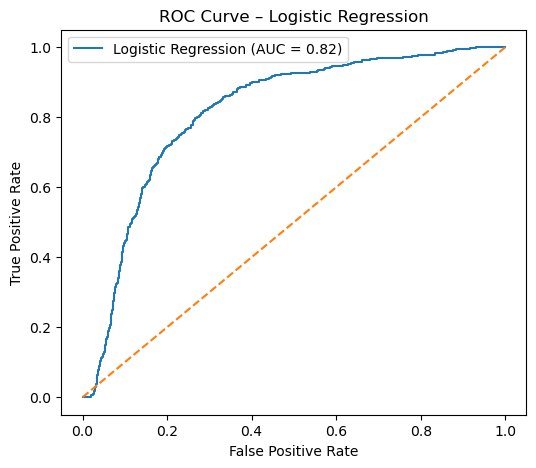

In [27]:
# Predict probabilities for Logistic Regression
y_test_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

# ROC values
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_prob_lr)
auc_lr = roc_auc_score(y_test, y_test_prob_lr)

# Plot ROC
plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression")
plt.legend()
plt.show()

- ## ROC Curve for Random Forest

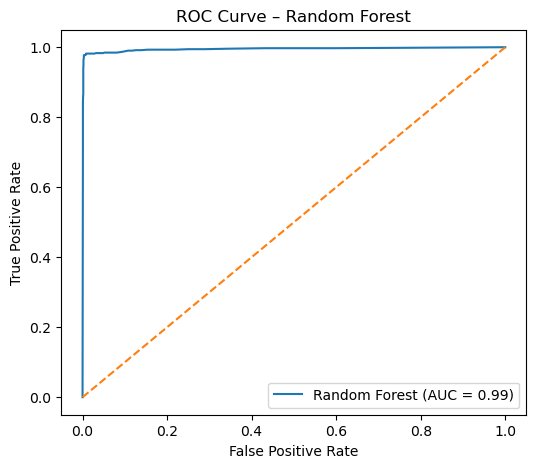

In [28]:
# Predict probabilities for Random Forest
y_test_prob_rf = rf.predict_proba(X_test)[:, 1]

# ROC values
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_prob_rf)
auc_rf = roc_auc_score(y_test, y_test_prob_rf)

# Plot ROC
plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Random Forest")
plt.legend()
plt.show()

- ## ROC Curve for Gradient Boosting

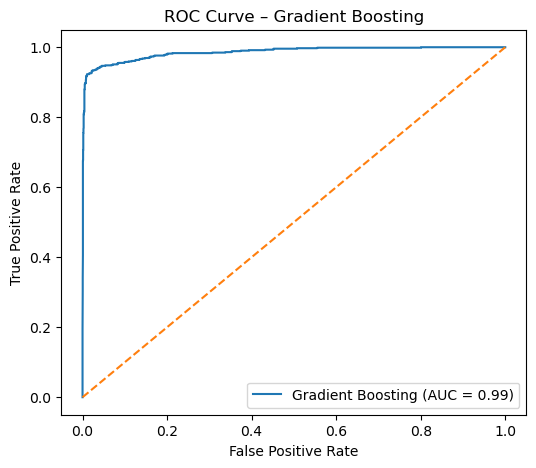

In [29]:
# Predict probabilities for Gradient Boosting
y_test_prob_gb = gb.predict_proba(X_test)[:, 1]

# ROC values
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_test_prob_gb)
auc_gb = roc_auc_score(y_test, y_test_prob_gb)

# Plot ROC
plt.figure(figsize=(6, 5))
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {auc_gb:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Gradient Boosting")
plt.legend()
plt.show()

### ROC Curve Analysis
- ROC curves compare the true positive rate against the false positive rate.
- Random Forest shows the highest AUC value, indicating superior class
  separability.
- Gradient Boosting also performs well but slightly below Random Forest.
- Logistic Regression provides the weakest ROC performance among the three.


# Confusion Matrix & Metric Justification
- ## Confusion Matrix (Random Forest – Best Model)

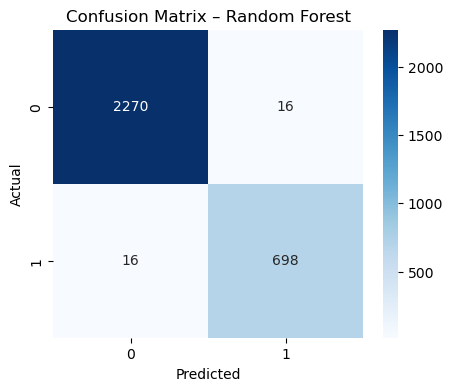

In [30]:
# Confusion Matrix for Random Forest
cm = confusion_matrix(y_test, y_test_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Random Forest")
plt.show()

### Precision vs Recall – Metric Justification
- In employee turnover prediction, Recall is more important than Precision.
- A false negative (predicting an employee will stay when they actually leave)
  results in missed retention opportunities.
- A false positive (predicting an employee will leave when they stay) is less
  costly, as preventive actions can still be beneficial.
- Therefore, Recall is the most critical metric for evaluating the model.


# Retention Strategies for Targeted Employees

## Predict Turnover Probability on Test Data

In [31]:
# Predict probability of employee leaving (class = 1) using best model
y_test_prob_rf = rf.predict_proba(X_test)[:, 1]

# Create a dataframe with probabilities
risk_df = X_test.copy()
risk_df['turnover_probability'] = y_test_prob_rf

risk_df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium,turnover_probability
10627,0.98,0.77,3,191,2,0,0,False,False,False,False,False,False,True,False,False,False,True,0.00
2703,0.76,0.93,3,271,5,0,0,False,False,True,False,False,False,False,False,False,True,False,0.59
6059,0.70,0.93,3,185,4,0,0,False,True,False,False,False,False,False,False,False,False,True,0.06
3258,0.48,0.61,3,223,3,1,0,False,False,False,False,False,False,False,True,False,False,True,0.01
4565,0.57,0.90,3,144,2,0,0,False,False,False,False,False,False,False,False,False,False,True,0.00


## Categorize Employees into Risk Zones
As per the problem statement:

- Safe Zone (Green): < 20%

- Low Risk (Yellow): 20% – 60%

- Medium Risk (Orange): 60% – 90%

- High Risk (Red): > 90%

In [32]:
# Function to assign risk zones
def assign_risk_zone(prob):
    if prob < 0.20:
        return "Safe Zone (Green)"
    elif prob < 0.60:
        return "Low Risk (Yellow)"
    elif prob < 0.90:
        return "Medium Risk (Orange)"
    else:
        return "High Risk (Red)"

# Apply function
risk_df['risk_zone'] = risk_df['turnover_probability'].apply(assign_risk_zone)

risk_df['risk_zone'].value_counts()

risk_zone
Safe Zone (Green)       2173
High Risk (Red)          646
Low Risk (Yellow)        122
Medium Risk (Orange)      59
Name: count, dtype: int64

### 

View Sample Employees from Each Risk Zone

In [33]:
# View few high-risk employees
risk_df[risk_df['risk_zone'] == "High Risk (Red)"].head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium,turnover_probability,risk_zone
14892,0.11,0.92,6,281,4,0,0,False,False,False,False,False,False,True,False,False,False,True,1.0,High Risk (Red)
1246,0.43,0.49,2,155,3,0,0,False,False,False,False,False,False,True,False,False,False,True,1.0,High Risk (Red)
14278,0.90,0.98,4,264,6,0,0,False,False,False,False,False,True,False,False,False,False,True,1.0,High Risk (Red)
12238,0.43,0.53,2,146,3,0,0,False,False,False,False,True,False,False,False,False,True,False,1.0,High Risk (Red)
14859,0.45,0.54,2,129,3,0,0,False,False,False,False,False,False,False,False,True,False,True,1.0,High Risk (Red)


### Risk Zone Interpretation
### Employee Risk Segmentation
- Employees are segmented into four risk zones based on their predicted
  probability of leaving.
- This segmentation helps HR prioritize retention strategies.
- High-risk employees require immediate intervention, while low-risk and
  safe employees require monitoring.


# Retention Strategies

## Retention Strategies by Risk Zone

**Safe Zone (Green – Score < 20%)**
- Maintain current engagement levels
- Provide recognition and career growth opportunities
- Continue regular feedback and performance reviews

**Low Risk Zone (Yellow – 20% < Score < 60%)**
- Conduct periodic one-on-one discussions
- Offer skill development and training programs
- Improve work-life balance and team engagement

**Medium Risk Zone (Orange – 60% < Score < 90%)**
- Immediate managerial intervention required
- Review workload, compensation, and growth opportunities
- Provide incentives, promotions, or role changes

**High Risk Zone (Red – Score > 90%)**
- Critical employees requiring urgent retention actions
- Conduct exit-risk interviews
- Offer salary revisions, role redesign, or retention bonuses
- If retention is not possible, initiate knowledge transfer plans


                              ---------------------- The End -----------------------

#### Saving the trained model

In [39]:
import pickle

# Save the best classification model (Random Forest)
pickle.dump(rf, open("model/employee_turnover_rf_model.pkl", "wb"))